In [1]:
import pandas as pd
import numpy as np
import pickle
import torch
import transformers
from transformers import AutoTokenizer, AutoModel, BertTokenizer, BertModel
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

from torch import nn
from torch.utils.data import DataLoader, Dataset



In [4]:
%pip install "numpy<2.0" --no-cache-dir

   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
   ----------------------------- ---------- 11.5/15.5 MB 72.3 MB/s eta 0:00:01
   ---------------------------------------- 15.5/15.5 MB 81.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.5.2
    Uninstalling numpy-2.5.2:
      Successfully uninstalled numpy-2.5.2
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ml-dtypes 0.6.0 requires numpy>=2.0.0, but you have numpy 1.26.4 which is incompatible.
streamlit 1.37.1 requires pillow<11,>=7.1.0, but you have pillow 12.3.0 which is incompatible.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 7.36.0 which is incompatible.
streamlit 1.37.1 requires rich<14,>=10.14.0, but you have rich 15.0.0 which is incompatible.


In [8]:
print(transformers.__version__)

5.16.1


In [5]:
df = pd.read_csv('filtered_movie_plots.csv')
df.shape

(997, 8)

In [2]:
import torch
from transformers import AutoTokenizer, AutoModel

# 1. Load ModernBERT (Drop-in replacement for your script)
tokenizer = AutoTokenizer.from_pretrained("answerdotai/ModernBERT-base")
model = AutoModel.from_pretrained("answerdotai/ModernBERT-base")

model.eval()

# Function to get embeddings for a single text
def get_embedding(text):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=8128)
    with torch.no_grad():
        outputs = model(**inputs)
    # Use the [CLS] token embedding as sentence embedding
    cls_embedding = outputs.last_hidden_state[:, 0, :]
    return cls_embedding.squeeze().numpy()


Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

[transformers] ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
decoder.bias      | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [2]:
model.save_pretrained("ModernBERT-base")
tokenizer.save_pretrained("ModernBERT-base")

NameError: name 'model' is not defined

In [3]:
tokenizer = AutoTokenizer.from_pretrained("ModernBERT-base")
model = AutoModel.from_pretrained("ModernBERT-base")

Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

In [ ]:
df['embeddings'] = df['Plot'].apply(get_embedding)

In [ ]:
df['embeddings'].head()

0    [0.18222985, -0.95408446, -0.25819746, 0.42745...
1    [0.38785553, -0.48290956, -0.818788, -0.063842...
2    [0.23674302, -0.7226157, -0.7158383, 0.3756947...
3    [0.7267924, -0.50657856, -0.46245947, 0.068034...
4    [-0.02754683, -0.77008986, -0.43686825, 0.2312...
Name: embeddings, dtype: object

In [12]:
df.dtypes

Release Year         int64
Title               object
Origin/Ethnicity    object
Director            object
Cast                object
Genre               object
Wiki Page           object
Plot                object
embeddings          object
dtype: object

In [8]:
df.to_csv('filtered_movie_plots_with_embeddings.csv', index=False)

In [9]:
new_df = pd.read_csv('filtered_movie_plots_with_embeddings.csv')

In [14]:
new_df.to_parquet('movies_with_embeddings.parquet')

In [15]:
df = pd.read_parquet('movies_with_embeddings.parquet')
df.dtypes

Release Year         int64
Title               object
Origin/Ethnicity    object
Director            object
Cast                object
Genre               object
Wiki Page           object
Plot                object
embeddings          object
dtype: object

In [24]:
df.dtypes

Release Year         int64
Title               object
Origin/Ethnicity    object
Director            object
Cast                object
Genre               object
Wiki Page           object
Plot                object
embeddings          object
dtype: object

In [26]:
df.embeddings.head()

0    [0.182229847, -0.954084456, -0.258197457, 0.42...
1    [0.38785553, -0.48290956, -0.818787992, -0.063...
2    [0.236743018, -0.722615719, -0.715838313, 0.37...
3    [0.726792395, -0.506578565, -0.462459475, 0.06...
4    [-0.0275468305, -0.770089865, -0.43686825, 0.2...
Name: embeddings, dtype: object

In [34]:
X = np.stack(df['embeddings'].values)
le = LabelEncoder()
y_encoded = le.fit_transform(df['Genre'])


X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

clf = LogisticRegression(max_iter=1000)  # Increase max_iter to ensure convergence

# 2. Train the model ONLY on the training subset
clf.fit(X_train, y_train)

# 3. Check your TRUE performance on data the model has never seen before
y_pred_test = clf.predict(X_test)
print("True Test Accuracy:", accuracy_score(y_test, y_pred_test))
print("\nValidation Report:\n", classification_report(y_test, y_pred_test, target_names=le.classes_))


True Test Accuracy: 0.395

Validation Report:
               precision    recall  f1-score   support

      action       0.50      0.45      0.48        22
   animation       0.43      0.45      0.44        20
       anime       0.81      0.76      0.79        17
      comedy       0.36      0.45      0.40        22
       drama       0.27      0.17      0.21        23
      family       0.00      0.00      0.00        12
     fantasy       0.14      0.12      0.13        16
      horror       0.50      0.43      0.47        23
     romance       0.45      0.57      0.50        23
    thriller       0.28      0.36      0.31        22

    accuracy                           0.40       200
   macro avg       0.37      0.38      0.37       200
weighted avg       0.39      0.40      0.39       200



In [35]:
new_plot = f"""Dom Cobb and Arthur are "extractors" who perform corporate espionage using experimental dream-sharing technology to infiltrate their targets' subconscious and extract information. Their latest target, Saito, is impressed with Cobb's ability to layer multiple dreams within each other. He offers to hire Cobb for the ostensibly impossible job of implanting an idea into a person's subconscious; performing "inception" on Robert Fischer, the son of Saito's competitor Maurice Fischer, with the idea to dissolve his father's company. In return, Saito promises to clear Cobb's criminal status, allowing him to return home to his children.

Cobb accepts the offer and assembles his team: a forger named Eames, a chemist named Yusuf, and a college student named Ariadne. Ariadne is tasked with designing the dream's architecture, something Cobb himself cannot do for fear of being sabotaged by his mind's projection of his late wife, Mal. Maurice Fischer dies, and the team sedates Robert Fischer into a three-layer shared dream on an airplane to America bought by Saito. Time on each layer runs slower than the layer above, with one member staying behind on each to perform a music-synchronized "kick" (using the French song "Non, je ne regrette rien") to awaken dreamers on all three levels simultaneously.

The team abducts Robert in a city on the first level, but unknown to any team member, his subconscious projections, trained to anticipate such a scenario, attack them. After Saito is wounded, Cobb reveals that while dying in the dream would usually awaken dreamers, Yusuf's sedatives will instead send them into "Limbo": a world of infinite subconscious. Eames impersonates Robert's godfather, Peter Browning, to introduce the idea of an alternate will to dissolve the company.

Cobb explains to Ariadne that he and Mal entered Limbo while experimenting with dream-sharing, experiencing fifty years in one night due to the time dilation with reality. After waking up, Mal still believed she was dreaming. Attempting to "wake up," she committed suicide and framed Cobb for her murder to force him to do the same. Cobb fled the U.S., leaving his children behind.

Yusuf drives the team around the first level as they are sedated into the second level, a hotel dreamed by Arthur. Cobb persuades Robert that Browning has kidnapped him to stop the dissolution and that Cobb is a defensive projection, leading Robert to another third level deeper as part of a ruse to enter Robert's subconscious.

In the third level, the team infiltrates an alpine fortress with a projection of Maurice inside, where the inception itself can be performed. However, Yusuf performs his kick too soon by driving off a bridge, forcing Arthur and Eames to improvise a new set of kicks synchronized with them hitting the water by rigging an elevator and the fortress, respectively, with explosives. Mal then appears and kills Robert before he can be subjected to the inception; he and Saito are subsequently lost in Limbo, forcing Cobb and Ariadne to rescue them in time for Robert's inception and Eames's kick. Cobb reveals that during their time in Limbo, Mal refused to return to reality; Cobb had to convince her it was only a dream, accidentally incepting in her the belief that the real world was still a dream. Cobb makes peace with his part in Mal's death. Ariadne kills Mal's projection and wakes Robert up with a kick.

Revived into the third level, Robert discovers the planted idea: his dying father telling him to create something for himself. While Cobb searches for Saito in Limbo, the others ride the synced kicks back to reality. Cobb finds an aged Saito and reminds him of their agreement. The dreamers all awaken on the plane, and Saito makes a phone call. Arriving in Los Angeles, Cobb passes the immigration checkpoint, and his father-in-law accompanies him to his home. Cobb uses Mal's "totem" – a top that spins indefinitely in a dream – to test if he is indeed in the real world, but he chooses not to observe the result and instead joins his children."""

In [ ]:
# 2. Generate the embedding using your ModernBERT pipeline
# (Replace this with the exact function/code you used to get embeddings earlier)
new_embedding = get_embedding(new_plot)

# 3. Ensure it is a 2D array shape (1, embedding_dim) for the classifier
X_new = np.array(new_embedding).reshape(1, -1)

# 4. Predict the encoded class integer
predicted_encoded = clf.predict(X_new)

# 5. Convert the integer back to the actual genre name
predicted_genre = le.inverse_transform(predicted_encoded)

print(f"Predicted Genre: {predicted_genre}")

Predicted Genre: horror


In [32]:
df.Genre.value_counts()

Genre
action       112
comedy       112
drama        112
horror       112
romance      112
thriller     112
animation    101
anime         87
fantasy       79
family        58
Name: count, dtype: int64

In [28]:
df.head()

,Release Year,Title,Origin/Ethnicity,Director,Cast,Genre,Wiki Page,Plot,embeddings
0,2015,Temper,Telugu,Puri Jagannadh,"N. T. Rama Rao Jr., Kajal Aggarwal, Prakash Raj",action,https://en.wikipedia.org/wiki/Temper_(film),Daya is an orphan who grows up learning that a...,"[0.182229847, -0.954084456, -0.258197457, 0.42..."
1,2009,Fighting,American,Dito Montiel,"Channing Tatum, Terrence Howard",action,https://en.wikipedia.org/wiki/Fighting_(2009_f...,Present day New York City: Shawn MacArthur (Ch...,"[0.38785553, -0.48290956, -0.818787992, -0.063..."
2,2009,Newtonin Moondram Vidhi,Tamil,Thai Muthuselvam,"S. J. Surya, Sayali Bhagat, Rajiv Krishna\r\n",action,https://en.wikipedia.org/wiki/Newtonin_Moondra...,The film opens with a grim and bearded angry y...,"[0.236743018, -0.722615719, -0.715838313, 0.37..."
3,2012,Dark Tide,American,John Stockwell,"Halle Berry, Olivier Martinez, Ralph Brown, Lu...",action,https://en.wikipedia.org/wiki/Dark_Tide,Kate is a shark expert whose business has been...,"[0.726792395, -0.506578565, -0.462459475, 0.06..."
4,2011,Shakti,Telugu,Meher Ramesh,"Jr. NTR, Ileana D'Cruz, Manjari Phadnis, Jacki...",action,https://en.wikipedia.org/wiki/Shakti_(2011_film),Aishwarya (Ileana D'Cruz) is the daughter of c...,"[-0.0275468305, -0.770089865, -0.43686825, 0.2..."


In [3]:
df = pd.read_csv('wiki_movie_plots_deduped.csv')
df.isna().sum()

Release Year           0
Title                  0
Origin/Ethnicity       0
Director               0
Cast                1422
Genre                  0
Wiki Page              0
Plot                   0
dtype: int64

In [6]:
df.Genre.value_counts().head(11)

Genre
unknown      6083
drama        5964
comedy       4379
horror       1167
action       1098
thriller      966
romance       923
western       865
crime         568
adventure     526
musical       467
Name: count, dtype: int64

In [5]:
df = pd.read_csv('filtered_movie_plots_400Genres.csv')
df.Genre.value_counts()

Genre
action       400
adventure    400
comedy       400
crime        400
drama        400
horror       400
musical      400
romance      400
thriller     400
western      400
Name: count, dtype: int64

In [11]:
df['embeddings'] = df['Plot'].apply(get_embedding)

In [25]:
df.to_csv('filtered_movies_with_embeddings400.csv')

In [2]:
df = pd.read_csv('filtered_movies_with_embeddings400.csv')

In [3]:
df.Genre.value_counts()

Genre
action       400
adventure    400
comedy       400
crime        400
drama        400
horror       400
musical      400
romance      400
thriller     400
western      400
Name: count, dtype: int64

In [4]:
df.embeddings.head()

0    [ 3.51156026e-01 -3.54130566e-01 -4.20265108e-...
1    [-6.11529164e-02 -2.36796856e-01  1.36722103e-...
2    [ 5.74961603e-01 -1.13089287e+00 -6.60298944e-...
3    [ 1.17060721e-01 -9.89950597e-01 -6.88898802e-...
4    [ 2.63879865e-01 -2.32751444e-01 -8.77337873e-...
Name: embeddings, dtype: object

In [5]:
def clean_and_parse_embedding(text_string):
    # Remove any brackets, replace newlines with spaces, and split by whitespace
    cleaned = text_string.replace('[', '').replace(']', '').replace('\n', ' ').strip()
    # Convert the isolated numbers back into a true numeric float array
    return np.fromstring(cleaned, sep=' ')



In [6]:
df['embeddings'] = df['embeddings'].apply(clean_and_parse_embedding)

In [7]:
X = np.stack(df['embeddings'].values)
le = LabelEncoder()
y_encoded = le.fit_transform(df['Genre'])


X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)


In [8]:
grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}
clf = LogisticRegression(solver='saga', max_iter=1000)
scoring_metrics = {
    'accuracy': 'accuracy',
    'precision': 'precision_macro',  # Fixed
    'f1_macro': 'f1_macro',                # Fixed
    'recall': 'recall_macro'          # Fixed
}
# 3. Setup Grid Search
grid_search = GridSearchCV(
    clf, 
    grid,
    scoring=scoring_metrics,
    cv=5,    
    refit='f1_macro',
    n_jobs=-1
)
# 3. Setup Grid Search
grid_search.fit(X_train, y_train)

# 4. Get the best parameters and the best score
# print("Best parameters found: ", grid_search.best_params_)
# print("Best cross-validation F1 macro score: ", grid_search.best_score_)
# # 2. Train the model ONLY on the training subset
# clf.fit(X_train, y_train)

# # 3. Check your TRUE performance on data the model has never seen before
# y_pred_test = clf.predict(X_test)
# print("True Test Accuracy:", accuracy_score(y_test, y_pred_test))
# print("\nValidation Report:\n", classification_report(y_test, y_pred_test, target_names=le.classes_))


GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000, solver='saga'),
             n_jobs=-1, param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]},
             refit='f1_macro',
             scoring={'accuracy': 'accuracy', 'f1_macro': 'f1_macro',
                      'precision': 'precision_macro',
                      'recall': 'recall_macro'})

In [10]:
y_pred_test = grid_search.predict(X_test)
excel_df = pd.DataFrame({
    'y_true': le.inverse_transform(y_test),
    'y_pred': le.inverse_transform(y_pred_test)
})
excel_df.head( )

,y_true,y_pred
0,drama,drama
1,musical,musical
2,western,western
3,adventure,adventure
4,adventure,crime


In [12]:
print(" Test Accuracy:", accuracy_score(y_test, y_pred_test))
print("\nValidation Report:\n", classification_report(y_test, y_pred_test, target_names=le.classes_))


 Test Accuracy: 0.45375

Validation Report:
               precision    recall  f1-score   support

      action       0.41      0.42      0.42        80
   adventure       0.56      0.51      0.54        80
      comedy       0.34      0.24      0.28        80
       crime       0.42      0.47      0.44        80
       drama       0.22      0.19      0.20        80
      horror       0.61      0.66      0.63        80
     musical       0.51      0.61      0.56        80
     romance       0.42      0.54      0.47        80
    thriller       0.25      0.19      0.22        80
     western       0.65      0.70      0.67        80

    accuracy                           0.45       800
   macro avg       0.44      0.45      0.44       800
weighted avg       0.44      0.45      0.44       800



In [11]:
excel_df.to_excel('logistic_regression_predictions.xlsx', index=False)

In [15]:
with open('best_model_params.txt', 'w') as f:
    f.write("Best parameters found: " + str(grid_search.best_params_) + "\n")
    f.write("Best cross-validation F1 macro score: " + str(grid_search.best_score_) + "\n")

In [18]:
best_model = grid_search.best_estimator_

with open('best_logistic_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)


In [20]:
with open('best_logistic_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)


In [26]:
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

In [24]:
param_grid = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'n_estimators': [50, 100, 200]
}
rf = RandomForestClassifier(random_state=42)
scoring_metrics = {
    'accuracy': 'accuracy',
    'precision': 'precision_macro',  # Fixed
    'f1_macro': 'f1_macro',                # Fixed
    'recall': 'recall_macro'          # Fixed
}

rf_cv = GridSearchCV(
    rf,
    param_grid,
    scoring=scoring_metrics,
    cv=5,
    refit='f1_macro',
    n_jobs=-1
)
rf_cv.fit(X_train, y_train)
    


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             refit='f1_macro',
             scoring={'accuracy': 'accuracy', 'f1_macro': 'f1_macro',
                      'precision': 'precision_macro',
                      'recall': 'recall_macro'})

In [25]:
with open('best_forest_classifier.pkl', 'wb') as f:
    pickle.dump(rf_cv.best_estimator_, f)

In [24]:
df.shape

(4000, 9)

In [ ]:
# Sample dataset class
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding.input_ids.flatten(),
            'attention_mask': encoding.attention_mask.flatten(),
            'labels': torch.tensor(label, dtype=torch.float)
        }

# BERT classifier model
class BertClassifier(nn.Module):
    def __init__(self, n_classes):
        super(BertClassifier, self).__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.drop = nn.Dropout(p=0.3)
        self.out = nn.Linear(self.bert.config.hidden_size, n_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output
        output = self.drop(pooled_output)
        return self.out(output)

# Example usage
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
texts = ["This is a positive example.", "This is a negative example."]
labels = [[1, 0], [0, 1]]  # Example multi-labels
dataset = TextDataset(texts, labels, tokenizer, max_len=32)
dataloader = DataLoader(dataset, batch_size=2)

model = BertClassifier(n_classes=2)
optimizer = AdamW(model.parameters(), lr=2e-5)
criterion = nn.BCEWithLogitsLoss()

# Training loop (simplified)
model.train()
for batch in dataloader:
    optimizer.zero_grad()
    input_ids = batch['input_ids']
    attention_mask = batch['attention_mask']
    labels = batch['labels']
    outputs = model(input_ids, attention_mask)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    print(f"Loss: {loss.item()}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loss: 0.730118453502655


In [2]:
df = pd.read_csv('filtered_movie_plots_400Genres.csv')
df.head()

,Release Year,Title,Origin/Ethnicity,Director,Cast,Genre,Wiki Page,Plot
0,1997,Most Wanted,American,David Hogan,"Keenen Ivory Wayans, Jon Voight, Jill Hennessy",action,https://en.wikipedia.org/wiki/Most_Wanted_(199...,"James Dunn (Wayans), a United States Marine wh..."
1,2013,Adda,Telugu,Sai Karthik,"Sushanth, Shanvi Srivastava, Raghu Babu, Kota ...",action,https://en.wikipedia.org/wiki/Adda_(film),Abhi (Sushanth) is a young bloke who provides ...
2,2004,Six: The Mark Unleashed,American,Kevin Downes,"Stephen Baldwin, Eric Roberts, Kevin Downes",action,https://en.wikipedia.org/wiki/Six:_The_Mark_Un...,"The film is set in the end-times, or The Great..."
3,1982,Running on Empty (a.k.a. Fast Lane Fever),Australian,John Clark,"Deborah Conway, Max Cullen",action,https://en.wikipedia.org/wiki/Running_on_Empty...,Mike (Terry Serio) is a young man who is a bud...
4,2011,Mambattiyan,Tamil,Thyagarajan,"Prashanth, Meera Jasmine, Mumaith Khan",action,https://en.wikipedia.org/wiki/Mambattiyan,IG Ranjith (Prakash Raj) recalls the memories ...


In [28]:
%pip uninstall torch torchvision torchaudio -y

Found existing installation: torch 2.13.0
Uninstalling torch-2.13.0:
  Successfully uninstalled torch-2.13.0
Found existing installation: torchvision 0.28.0
Uninstalling torchvision-0.28.0:
  Successfully uninstalled torchvision-0.28.0
Found existing installation: torchaudio 2.11.0
Uninstalling torchaudio-2.11.0:
  Successfully uninstalled torchaudio-2.11.0
Note: you may need to restart the kernel to use updated packages.


You can safely remove it manually.
You can safely remove it manually.
You can safely remove it manually.


In [3]:
import torch
print("Is CUDA available?:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("PyTorch CUDA Version:", torch.version.cuda)
    print("Active GPU Device:", torch.cuda.get_device_name(0))

Is CUDA available?: True
PyTorch CUDA Version: 13.2
Active GPU Device: NVIDIA GeForce RTX 5060 Ti


In [35]:
torch.cuda.is_available()

False

In [33]:
torch.cuda.device_count()

0

In [4]:
with open('label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

y_encoded = le.transform(df['Genre'])
X_train, X_test, y_train, y_test = train_test_split(
    df['Plot'], y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [6]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding.input_ids.squeeze(0),
            'attention_mask': encoding.attention_mask.squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }
# BERT classifier model
class BertClassifier(nn.Module):
    def __init__(self, n_classes):
        super(BertClassifier, self).__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.drop = nn.Dropout(p=0.3)
        self.out = nn.Linear(self.bert.config.hidden_size, n_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output
        output = self.drop(pooled_output)
        return self.out(output)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
train_dataset = TextDataset(X_train.values if hasattr(X_train, 'values') else X_train, y_train.values if hasattr(y_train, 'values') else y_train, tokenizer, max_len=400)
test_dataset = TextDataset(X_test.values if hasattr(X_test, 'values') else X_test, y_test.values if hasattr(y_test, 'values') else y_test, tokenizer, max_len=400)

train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=16)

model = BertClassifier(n_classes=10).to(device)
optimizer = AdamW(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

# Training loop (simplified)
model.train()
NUM_EPOCHS = 6
for epoch in range(NUM_EPOCHS):  # Example: train for NUM_EPOCHS epochs
    for batch in train_dataloader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        print(f"Loss: {loss.item()}")
    print(f"Epoch {epoch} completed")



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loss: 2.459503173828125
Loss: 2.282572031021118
Loss: 2.2968289852142334
Loss: 2.362755298614502
Loss: 2.513270378112793
Loss: 2.340012550354004
Loss: 2.3932948112487793
Loss: 2.29457950592041
Loss: 2.2889347076416016
Loss: 2.3157923221588135
Loss: 2.382876396179199
Loss: 2.3813483715057373
Loss: 2.367130756378174
Loss: 2.4105067253112793
Loss: 2.323777198791504
Loss: 2.391141414642334
Loss: 2.322601079940796
Loss: 2.2281219959259033
Loss: 2.3412208557128906
Loss: 2.213754653930664
Loss: 2.3842105865478516
Loss: 2.3359930515289307
Loss: 2.367560386657715
Loss: 2.462623119354248
Loss: 2.280698776245117
Loss: 2.311652660369873
Loss: 2.2967476844787598
Loss: 2.251298427581787
Loss: 2.3049263954162598
Loss: 2.312640905380249
Loss: 2.23714017868042
Loss: 2.3595478534698486
Loss: 2.2638351917266846
Loss: 2.3908677101135254
Loss: 2.249373197555542
Loss: 2.269010543823242
Loss: 2.2119925022125244
Loss: 2.1383004188537598
Loss: 2.298870325088501
Loss: 2.2084450721740723
Loss: 2.1926236152648926

In [7]:
torch.save(model.state_dict(), 'bert_classifier_model.pth')

In [5]:
for index, genre in enumerate(le.classes_):
    print(f"Index {index}: {genre}")

Index 0: action
Index 1: adventure
Index 2: comedy
Index 3: crime
Index 4: drama
Index 5: horror
Index 6: musical
Index 7: romance
Index 8: thriller
Index 9: western


In [7]:
model.eval()
total_correct = 0
total_samples = 0
    
with torch.no_grad():
    for batch in test_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
            
        outputs = model(input_ids, attention_mask)
        _, predictions = torch.max(outputs, dim=1)
            
        total_correct += torch.sum(predictions == labels).item()
        total_samples += labels.size(0)
            
    val_accuracy = total_correct / total_samples
print(f"Epoch {epoch} | Test Accuracy: {val_accuracy * 100:.2f}%")

Epoch 2 | Test Accuracy: 59.25%


In [8]:
from sklearn.metrics import classification_report

# 1. Clear array caches to prevent accumulation errors
all_predictions = []
all_true_labels = []

# 2. Put model in evaluation mode and collect predictions
model.eval()
with torch.no_grad():
    for batch in test_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        outputs = model(input_ids, attention_mask)
        _, predictions = torch.max(outputs, dim=1)
        
        all_predictions.extend(predictions.cpu().numpy())
        all_true_labels.extend(labels.cpu().numpy())

# 3. Pull the categories directly from your LabelEncoder (le) in correct order
genre_names = list(le.classes_)

print("\n========================================================")
print("             BERT GENRE CLASSIFICATION REPORT           ")
print("========================================================\n")

print(classification_report(
    all_true_labels, 
    all_predictions, 
    target_names=genre_names,
    zero_division=0
))



             BERT GENRE CLASSIFICATION REPORT           

              precision    recall  f1-score   support

      action       0.57      0.54      0.55        80
   adventure       0.63      0.80      0.71        80
      comedy       0.54      0.09      0.15        80
       crime       0.74      0.54      0.62        80
       drama       0.44      0.41      0.43        80
      horror       0.64      0.86      0.73        80
     musical       0.73      0.68      0.70        80
     romance       0.49      0.64      0.55        80
    thriller       0.34      0.42      0.38        80
     western       0.82      0.95      0.88        80

    accuracy                           0.59       800
   macro avg       0.59      0.59      0.57       800
weighted avg       0.59      0.59      0.57       800



In [10]:
def predict_custom_movie_genre(plot_text, model, tokenizer, label_encoder, max_len=400):
    # 1. Put the model in evaluation mode
    model.eval()
    
    # 2. Tokenize the incoming string exactly like the dataset class does
    encoding = tokenizer(
        plot_text,
        add_special_tokens=True,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    
    # 3. Route the input tensors to your GPU
    input_ids = encoding.input_ids.to(device)
    attention_mask = encoding.attention_mask.to(device)
    
    # 4. Predict the class index without building a gradient tree
    with torch.no_grad():
        outputs = model(input_ids, attention_mask)
        _, prediction_idx = torch.max(outputs, dim=1)
        
    # 5. Automatically map the raw integer back to the string label using your 'le'
    predicted_genre_string = label_encoder.inverse_transform([prediction_idx.item()])[0]
    
    return predicted_genre_string

# =====================================================================
# CHANGE THIS STRING TO TEST ANY PLOT SUMMARY YOU WANT!
# =====================================================================
sample_movie_plot = f"""Dom Cobb and Arthur are "extractors" who perform corporate espionage using experimental dream-sharing technology to infiltrate their targets' subconscious and extract information. Their latest target, Saito, is impressed with Cobb's ability to layer multiple dreams within each other. He offers to hire Cobb for the ostensibly impossible job of implanting an idea into a person's subconscious; performing "inception" on Robert Fischer, the son of Saito's competitor Maurice Fischer, with the idea to dissolve his father's company. In return, Saito promises to clear Cobb's criminal status, allowing him to return home to his children.

Cobb accepts the offer and assembles his team: a forger named Eames, a chemist named Yusuf, and a college student named Ariadne. Ariadne is tasked with designing the dream's architecture, something Cobb himself cannot do for fear of being sabotaged by his mind's projection of his late wife, Mal. Maurice Fischer dies, and the team sedates Robert Fischer into a three-layer shared dream on an airplane to America bought by Saito. Time on each layer runs slower than the layer above, with one member staying behind on each to perform a music-synchronized "kick" (using the French song "Non, je ne regrette rien") to awaken dreamers on all three levels simultaneously.

The team abducts Robert in a city on the first level, but unknown to any team member, his subconscious projections, trained to anticipate such a scenario, attack them. After Saito is wounded, Cobb reveals that while dying in the dream would usually awaken dreamers, Yusuf's sedatives will instead send them into "Limbo": a world of infinite subconscious. Eames impersonates Robert's godfather, Peter Browning, to introduce the idea of an alternate will to dissolve the company.

Cobb explains to Ariadne that he and Mal entered Limbo while experimenting with dream-sharing, experiencing fifty years in one night due to the time dilation with reality. After waking up, Mal still believed she was dreaming. Attempting to "wake up," she committed suicide and framed Cobb for her murder to force him to do the same. Cobb fled the U.S., leaving his children behind.

Yusuf drives the team around the first level as they are sedated into the second level, a hotel dreamed by Arthur. Cobb persuades Robert that Browning has kidnapped him to stop the dissolution and that Cobb is a defensive projection, leading Robert to another third level deeper as part of a ruse to enter Robert's subconscious.

In the third level, the team infiltrates an alpine fortress with a projection of Maurice inside, where the inception itself can be performed. However, Yusuf performs his kick too soon by driving off a bridge, forcing Arthur and Eames to improvise a new set of kicks synchronized with them hitting the water by rigging an elevator and the fortress, respectively, with explosives. Mal then appears and kills Robert before he can be subjected to the inception; he and Saito are subsequently lost in Limbo, forcing Cobb and Ariadne to rescue them in time for Robert's inception and Eames's kick. Cobb reveals that during their time in Limbo, Mal refused to return to reality; Cobb had to convince her it was only a dream, accidentally incepting in her the belief that the real world was still a dream. Cobb makes peace with his part in Mal's death. Ariadne kills Mal's projection and wakes Robert up with a kick.

Revived into the third level, Robert discovers the planted idea: his dying father telling him to create something for himself. While Cobb searches for Saito in Limbo, the others ride the synced kicks back to reality. Cobb finds an aged Saito and reminds him of their agreement. The dreamers all awaken on the plane, and Saito makes a phone call. Arriving in Los Angeles, Cobb passes the immigration checkpoint, and his father-in-law accompanies him to his home. Cobb uses Mal's "totem" – a top that spins indefinitely in a dream – to test if he is indeed in the real world, but he chooses not to observe the result and instead joins his children."""

# Run the prediction function
predicted_genre = predict_custom_movie_genre(sample_movie_plot, model, tokenizer, le)

print("=========================================")
print("            MODEL INFERENCE              ")
print("=========================================")
print(f"Plot Provided: '{sample_movie_plot}'\n")
print(f"🎯 Predicted Genre Tag: {predicted_genre.upper()}")


            MODEL INFERENCE              
Plot Provided: 'Dom Cobb and Arthur are "extractors" who perform corporate espionage using experimental dream-sharing technology to infiltrate their targets' subconscious and extract information. Their latest target, Saito, is impressed with Cobb's ability to layer multiple dreams within each other. He offers to hire Cobb for the ostensibly impossible job of implanting an idea into a person's subconscious; performing "inception" on Robert Fischer, the son of Saito's competitor Maurice Fischer, with the idea to dissolve his father's company. In return, Saito promises to clear Cobb's criminal status, allowing him to return home to his children.

Cobb accepts the offer and assembles his team: a forger named Eames, a chemist named Yusuf, and a college student named Ariadne. Ariadne is tasked with designing the dream's architecture, something Cobb himself cannot do for fear of being sabotaged by his mind's projection of his late wife, Mal. Maurice F

In [3]:
temp_df = pd.read_csv('scraped_movie_data_1980s.csv')
temp_df.head()

,revenue,budget
0,20423389.0,49000000.0
1,NaN,NaN
2,57661269.0,35000000.0
3,57200000.0,3000000.0
4,6939946.0,25000000.0


In [4]:
df = pd.read_csv("wiki_movie_plots_deduped.csv")
df.shape

(34886, 8)

In [9]:
df_1990s = df[(df['Release Year'] >= 1990) & (df['Release Year'] < 2000)]
df_1990s.shape

(4468, 8)

In [10]:
df_1990s_first_1300 = df_1990s.head(1300)
df_1990s_first_1300.shape

(1300, 8)

In [11]:
temp_df.shape

(1300, 2)

In [12]:
final_df_1990s_first_1300 = pd.concat(
    [
        df_1990s_first_1300.reset_index(drop=True),
        temp_df.reset_index(drop=True)
    ],
    axis=1
)

final_df_1990s_first_1300.shape

(1300, 10)

In [13]:
final_df_1990s_first_1300.head()

,Release Year,Title,Origin/Ethnicity,Director,Cast,Genre,Wiki Page,Plot,revenue,budget
0,1990,The Adventures of Ford Fairlane,American,Renny Harlin,"Andrew Dice Clay, Wayne Newton, Priscilla Pres...",comedy,https://en.wikipedia.org/wiki/The_Adventures_o...,Ford Fairlane (Andrew Dice Clay) is seen sitti...,20423389.0,49000000.0
1,1990,"After Dark, My Sweet",American,James Foley,"Jason Patric, Rachel Ward, Bruce Dern",mystery,"https://en.wikipedia.org/wiki/After_Dark,_My_S...","Ex-boxer Kevin ""Kid"" Collins is a drifter and ...",NaN,NaN
2,1990,Air America,American,Roger Spottiswoode,"Mel Gibson, Robert Downey, Jr., Nancy Travis",comedy,https://en.wikipedia.org/wiki/Air_America_(film),"In late 1969, Billy Covington (Robert Downey J...",57661269.0,35000000.0
3,1990,Alice,American,Woody Allen,"Mia Farrow, Joe Mantegna, William Hurt, Alec B...",comedy,https://en.wikipedia.org/wiki/Alice_(1990_film),Alice Tate is an upper-class New York housewif...,57200000.0,3000000.0
4,1990,Almost an Angel,American,John Cornell,"Paul Hogan, Elias Koteas, Charlton Heston",comedy,https://en.wikipedia.org/wiki/Almost_an_Angel,"Terry Dean (Paul Hogan), a professional burgla...",6939946.0,25000000.0


In [14]:
final_df_1990s_first_1300.to_csv('scraped_movie_data_part3.csv', index=False)

In [26]:
#loading the 3 csv files and concatenating them into one final dataset
df1 = pd.read_csv('scraped_movie_data_part1.csv')
df2 = pd.read_csv('scraped_movie_data_part2.csv')
df3 = pd.read_csv('scraped_movie_data_part3.csv')

df3 = df3.rename(columns={'Wiki Page':'Wiki_Page','revenue':'Revenue','budget':'Budget','Release Year':'Release_Year'}) 
final_df = pd.concat([df1, df2, df3], ignore_index=True)
final_df.shape

(2297, 10)

In [19]:
df1.head()

,Release_Year,Title,Origin/Ethnicity,Director,Cast,Genre,Wiki_Page,Plot,Revenue,Budget
0,2015,Temper,Telugu,Puri Jagannadh,"N. T. Rama Rao Jr., Kajal Aggarwal, Prakash Raj",action,https://en.wikipedia.org/wiki/Temper_(film),Daya is an orphan who grows up learning that a...,11600000.0,5400000.0
1,2009,Fighting,American,Dito Montiel,"Channing Tatum, Terrence Howard",action,https://en.wikipedia.org/wiki/Fighting_(2009_f...,Present day New York City: Shawn MacArthur (Ch...,32474120.0,NaN
2,2009,Newtonin Moondram Vidhi,Tamil,Thai Muthuselvam,"S. J. Surya, Sayali Bhagat, Rajiv Krishna\r\n",action,https://en.wikipedia.org/wiki/Newtonin_Moondra...,The film opens with a grim and bearded angry y...,NaN,NaN
3,2012,Dark Tide,American,John Stockwell,"Halle Berry, Olivier Martinez, Ralph Brown, Lu...",action,https://en.wikipedia.org/wiki/Dark_Tide,Kate is a shark expert whose business has been...,432274.0,25000000.0
4,2011,Shakti,Telugu,Meher Ramesh,"Jr. NTR, Ileana D'Cruz, Manjari Phadnis, Jacki...",action,https://en.wikipedia.org/wiki/Shakti_(2011_film),Aishwarya (Ileana D'Cruz) is the daughter of c...,NaN,NaN


In [21]:
df2.head()

,Release_Year,Title,Origin/Ethnicity,Director,Cast,Genre,Wiki_Page,Plot,Revenue,Budget
0,2008,Fireflies in the Garden,American,Dennis Lee,"Julia Roberts, Ryan Reynolds, Willem Dafoe, Em...",drama,https://en.wikipedia.org/wiki/Fireflies_in_the...,The story moves back and forth between the ado...,6692182.0,8000000.0
1,2007,Aha!,Bangladeshi,Enamul Kabir Nirjhor,"Humayun Faridi, Tariq Anam Khan, Fazlur Rahman...",drama,https://en.wikipedia.org/wiki/Aha!_(film),Mr. Mallik (Tariq Anam Khan) lives in an about...,NaN,NaN
2,2010,The Hangman,Bollywood,Vishal Bhandari,"Om Puri, Shreyas Talpade, Gulshan Grover, Smit...",drama,https://en.wikipedia.org/wiki/The_Hangman_(201...,"The Hangman, starring internationally acclaime...",NaN,NaN
3,2014,Jamesy Boy,American,Trevor White,Spencer Lofranco\r\nMary-Louise Parker\r\nTais...,drama,https://en.wikipedia.org/wiki/Jamesy_Boy,"James Burns is in prison for selling guns, dru...",NaN,NaN
4,2011,Funkytown,Canadian,Daniel Roby,"Patrick Huard, Raymond Bouchard, Geneviève Bro...",drama,https://en.wikipedia.org/wiki/Funkytown_(film),"Set in Montreal during the disco era, the film...",NaN,7300000.0


In [20]:
df3.head()

,Release Year,Title,Origin/Ethnicity,Director,Cast,Genre,Wiki Page,Plot,revenue,budget
0,1990,The Adventures of Ford Fairlane,American,Renny Harlin,"Andrew Dice Clay, Wayne Newton, Priscilla Pres...",comedy,https://en.wikipedia.org/wiki/The_Adventures_o...,Ford Fairlane (Andrew Dice Clay) is seen sitti...,20423389.0,49000000.0
1,1990,"After Dark, My Sweet",American,James Foley,"Jason Patric, Rachel Ward, Bruce Dern",mystery,"https://en.wikipedia.org/wiki/After_Dark,_My_S...","Ex-boxer Kevin ""Kid"" Collins is a drifter and ...",NaN,NaN
2,1990,Air America,American,Roger Spottiswoode,"Mel Gibson, Robert Downey, Jr., Nancy Travis",comedy,https://en.wikipedia.org/wiki/Air_America_(film),"In late 1969, Billy Covington (Robert Downey J...",57661269.0,35000000.0
3,1990,Alice,American,Woody Allen,"Mia Farrow, Joe Mantegna, William Hurt, Alec B...",comedy,https://en.wikipedia.org/wiki/Alice_(1990_film),Alice Tate is an upper-class New York housewif...,57200000.0,3000000.0
4,1990,Almost an Angel,American,John Cornell,"Paul Hogan, Elias Koteas, Charlton Heston",comedy,https://en.wikipedia.org/wiki/Almost_an_Angel,"Terry Dean (Paul Hogan), a professional burgla...",6939946.0,25000000.0


In [31]:
final_df.head()

,Release_Year,Title,Origin/Ethnicity,Director,Cast,Genre,Wiki_Page,Plot,Revenue,Budget
0,2015,Temper,Telugu,Puri Jagannadh,"N. T. Rama Rao Jr., Kajal Aggarwal, Prakash Raj",action,https://en.wikipedia.org/wiki/Temper_(film),Daya is an orphan who grows up learning that a...,11600000.0,5400000.0
1,2009,Fighting,American,Dito Montiel,"Channing Tatum, Terrence Howard",action,https://en.wikipedia.org/wiki/Fighting_(2009_f...,Present day New York City: Shawn MacArthur (Ch...,32474120.0,NaN
2,2009,Newtonin Moondram Vidhi,Tamil,Thai Muthuselvam,"S. J. Surya, Sayali Bhagat, Rajiv Krishna\r\n",action,https://en.wikipedia.org/wiki/Newtonin_Moondra...,The film opens with a grim and bearded angry y...,NaN,NaN
3,2012,Dark Tide,American,John Stockwell,"Halle Berry, Olivier Martinez, Ralph Brown, Lu...",action,https://en.wikipedia.org/wiki/Dark_Tide,Kate is a shark expert whose business has been...,432274.0,25000000.0
4,2011,Shakti,Telugu,Meher Ramesh,"Jr. NTR, Ileana D'Cruz, Manjari Phadnis, Jacki...",action,https://en.wikipedia.org/wiki/Shakti_(2011_film),Aishwarya (Ileana D'Cruz) is the daughter of c...,NaN,NaN


In [34]:
final_df.head()

,Release_Year,Title,Origin/Ethnicity,Director,Cast,Genre,Wiki_Page,Plot,Revenue,Budget
0,2015,Temper,Telugu,Puri Jagannadh,"N. T. Rama Rao Jr., Kajal Aggarwal, Prakash Raj",action,https://en.wikipedia.org/wiki/Temper_(film),Daya is an orphan who grows up learning that a...,11600000.0,5400000.0
1,2009,Fighting,American,Dito Montiel,"Channing Tatum, Terrence Howard",action,https://en.wikipedia.org/wiki/Fighting_(2009_f...,Present day New York City: Shawn MacArthur (Ch...,32474120.0,NaN
2,2009,Newtonin Moondram Vidhi,Tamil,Thai Muthuselvam,"S. J. Surya, Sayali Bhagat, Rajiv Krishna\r\n",action,https://en.wikipedia.org/wiki/Newtonin_Moondra...,The film opens with a grim and bearded angry y...,NaN,NaN
3,2012,Dark Tide,American,John Stockwell,"Halle Berry, Olivier Martinez, Ralph Brown, Lu...",action,https://en.wikipedia.org/wiki/Dark_Tide,Kate is a shark expert whose business has been...,432274.0,25000000.0
4,2011,Shakti,Telugu,Meher Ramesh,"Jr. NTR, Ileana D'Cruz, Manjari Phadnis, Jacki...",action,https://en.wikipedia.org/wiki/Shakti_(2011_film),Aishwarya (Ileana D'Cruz) is the daughter of c...,NaN,NaN


In [35]:
final_df.to_csv('scraped_movie_data_final.csv', index=False)

In [2]:
df_scraped = pd.read_csv('scraped_movie_data_final.csv')
df_scraped.head()

,Release_Year,Title,Origin/Ethnicity,Director,Cast,Genre,Wiki_Page,Plot,Revenue,Budget
0,2015,Temper,Telugu,Puri Jagannadh,"N. T. Rama Rao Jr., Kajal Aggarwal, Prakash Raj",action,https://en.wikipedia.org/wiki/Temper_(film),Daya is an orphan who grows up learning that a...,11600000.0,5400000.0
1,2009,Fighting,American,Dito Montiel,"Channing Tatum, Terrence Howard",action,https://en.wikipedia.org/wiki/Fighting_(2009_f...,Present day New York City: Shawn MacArthur (Ch...,32474120.0,NaN
2,2009,Newtonin Moondram Vidhi,Tamil,Thai Muthuselvam,"S. J. Surya, Sayali Bhagat, Rajiv Krishna\r\n",action,https://en.wikipedia.org/wiki/Newtonin_Moondra...,The film opens with a grim and bearded angry y...,NaN,NaN
3,2012,Dark Tide,American,John Stockwell,"Halle Berry, Olivier Martinez, Ralph Brown, Lu...",action,https://en.wikipedia.org/wiki/Dark_Tide,Kate is a shark expert whose business has been...,432274.0,25000000.0
4,2011,Shakti,Telugu,Meher Ramesh,"Jr. NTR, Ileana D'Cruz, Manjari Phadnis, Jacki...",action,https://en.wikipedia.org/wiki/Shakti_(2011_film),Aishwarya (Ileana D'Cruz) is the daughter of c...,NaN,NaN


In [20]:
df_scraped.Revenue.head()

0    11600000.0
1    32474120.0
2           NaN
3      432274.0
4           NaN
Name: Revenue, dtype: float64

In [21]:
df_scraped.isna().sum()

Release_Year           0
Title                  0
Origin/Ethnicity       0
Director               0
Cast                 126
Genre                  0
Wiki_Page              0
Plot                   0
Revenue             1010
Budget              1127
dtype: int64

In [3]:
#dropping rows with missing values in the either 'revenue' or 'budget' columns
df_scraped_cleaned = df_scraped.dropna(subset=['Revenue', 'Budget']).reset_index(drop=True)
df_scraped_cleaned.shape

(1058, 10)

In [23]:
df_scraped_cleaned.head()

,Release_Year,Title,Origin/Ethnicity,Director,Cast,Genre,Wiki_Page,Plot,Revenue,Budget
0,2015,Temper,Telugu,Puri Jagannadh,"N. T. Rama Rao Jr., Kajal Aggarwal, Prakash Raj",action,https://en.wikipedia.org/wiki/Temper_(film),Daya is an orphan who grows up learning that a...,11600000.0,5400000.0
1,2012,Dark Tide,American,John Stockwell,"Halle Berry, Olivier Martinez, Ralph Brown, Lu...",action,https://en.wikipedia.org/wiki/Dark_Tide,Kate is a shark expert whose business has been...,432274.0,25000000.0
2,2010,Machete,American,"Robert Rodriguez, Ethan Maniquis","Danny Trejo, Michelle Rodriguez, Cheech Marin,...",action,https://en.wikipedia.org/wiki/Machete_(2010_film),"Mexico: Machete Cortez (Danny Trejo), a former...",45491656.0,10500000.0
3,2012,"Expendables 2, TheThe Expendables 2",American,Simon West,"Sylvester Stallone, Jason Statham, Jet Li, Dol...",action,https://en.wikipedia.org/wiki/The_Expendables_2,"The Expendables—leader Barney Ross, knife spec...",314975955.0,100000000.0
4,2002,Ballistic: Ecks vs. Sever,American,Wych Kaosayananda,"Antonio Banderas, Lucy Liu, Gregg Henry, Ray P...",action,https://en.wikipedia.org/wiki/Ballistic:_Ecks_...,Returning home with his mother Vinn (Talisa So...,19924033.0,70000000.0


In [8]:
df_scraped_cleaned.dtypes

Release_Year          int64
Title                object
Origin/Ethnicity     object
Director             object
Cast                 object
Genre                object
Wiki_Page            object
Plot                 object
Revenue             float64
Budget              float64
dtype: object

In [4]:
#creating a new column 'commercial_success' which is 1 if revenue is 2 times more than the budget, else 0
df_scraped_cleaned['commercial_success'] = df_scraped_cleaned.apply(lambda row: 1 if row['Revenue'] >= 2 * row['Budget'] else 0, axis=1)
df_scraped_cleaned.head()

,Release_Year,Title,Origin/Ethnicity,Director,Cast,Genre,Wiki_Page,Plot,Revenue,Budget,commercial_success
0,2015,Temper,Telugu,Puri Jagannadh,"N. T. Rama Rao Jr., Kajal Aggarwal, Prakash Raj",action,https://en.wikipedia.org/wiki/Temper_(film),Daya is an orphan who grows up learning that a...,11600000.0,5400000.0,1
1,2012,Dark Tide,American,John Stockwell,"Halle Berry, Olivier Martinez, Ralph Brown, Lu...",action,https://en.wikipedia.org/wiki/Dark_Tide,Kate is a shark expert whose business has been...,432274.0,25000000.0,0
2,2010,Machete,American,"Robert Rodriguez, Ethan Maniquis","Danny Trejo, Michelle Rodriguez, Cheech Marin,...",action,https://en.wikipedia.org/wiki/Machete_(2010_film),"Mexico: Machete Cortez (Danny Trejo), a former...",45491656.0,10500000.0,1
3,2012,"Expendables 2, TheThe Expendables 2",American,Simon West,"Sylvester Stallone, Jason Statham, Jet Li, Dol...",action,https://en.wikipedia.org/wiki/The_Expendables_2,"The Expendables—leader Barney Ross, knife spec...",314975955.0,100000000.0,1
4,2002,Ballistic: Ecks vs. Sever,American,Wych Kaosayananda,"Antonio Banderas, Lucy Liu, Gregg Henry, Ray P...",action,https://en.wikipedia.org/wiki/Ballistic:_Ecks_...,Returning home with his mother Vinn (Talisa So...,19924033.0,70000000.0,0


In [5]:
df_scraped_cleaned = df_scraped_cleaned.copy()

class TextDataset(Dataset):
    def __init__(self, texts, budgets, labels, tokenizer, max_len):
        self.texts = texts.reset_index(drop=True) if hasattr(texts, 'reset_index') else texts
        self.budgets = budgets.reset_index(drop=True) if hasattr(budgets, 'reset_index') else budgets
        self.labels = labels.reset_index(drop=True) if hasattr(labels, 'reset_index') else labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding.input_ids.squeeze(0),
            'attention_mask': encoding.attention_mask.squeeze(0),
            'labels': torch.tensor(int(self.labels[idx]), dtype=torch.long),
            'budget': torch.tensor(float(self.budgets[idx]), dtype=torch.float32)
        }

class BertClassifier(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.drop = nn.Dropout(p=0.3)
        self.out = nn.Linear(self.bert.config.hidden_size + 1, n_classes)

    def forward(self, input_ids, attention_mask, budget):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = self.drop(outputs.pooler_output)
        budget_feature = budget.float().view(-1, 1)
        combined = torch.cat((pooled_output, budget_feature), dim=1)
        return self.out(combined)


In [6]:


# Split the data while keeping text, budget, and label rows aligned.
train_df, test_df = train_test_split(
    df_scraped_cleaned,
    test_size=0.2,
    random_state=42,
    stratify=df_scraped_cleaned['commercial_success']
)

# Fit StandardScaler on training budgets only to avoid test-set leakage.
budget_scaler = StandardScaler()
train_budgets = budget_scaler.fit_transform(train_df[['Budget']]).flatten()
test_budgets = budget_scaler.transform(test_df[['Budget']]).flatten()

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
train_dataset = TextDataset(
    train_df['Plot'], train_budgets, train_df['commercial_success'], tokenizer, max_len=400
)
test_dataset = TextDataset(
    test_df['Plot'], test_budgets, test_df['commercial_success'], tokenizer, max_len=400
)

train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=16)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BertClassifier(n_classes=2).to(device)
optimizer = AdamW(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

NUM_EPOCHS = 5
for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0.0

    for batch in train_dataloader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        budget = batch['budget'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask, budget)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(
        f'Epoch {epoch + 1}/{NUM_EPOCHS} | '
        f'Loss: {total_loss / len(train_dataloader):.4f}'
    )

# Save the model and the fitted scaler needed during inference.
# torch.save({
#     'model_state_dict': model.state_dict(),
#     'budget_scaler_mean': budget_scaler.mean_,
#     'budget_scaler_scale': budget_scaler.scale_
# }, 'bert_commercial_success_classifier.pth')


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/5 | Loss: 0.7043
Epoch 2/5 | Loss: 0.6820
Epoch 3/5 | Loss: 0.6176
Epoch 4/5 | Loss: 0.5361
Epoch 5/5 | Loss: 0.3242


In [7]:
print(type(model))

<class '__main__.BertClassifier'>


In [9]:
torch.save({
    'model_state_dict': model.state_dict(),
    'budget_scaler_mean': budget_scaler.mean_,
    'budget_scaler_scale': budget_scaler.scale_,
    "class_names": {
        0: "Not commercially successful",
        1: "Commercially successful"
    }
}, 'bert_commercial_success_classifier.pth')


In [29]:
print("Selected device:", device)
print("Model device:", next(model.parameters()).device)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

Selected device: cuda
Model device: cuda:0
CUDA available: True
GPU: NVIDIA GeForce RTX 5060 Ti


In [27]:
print("Selected device:", device)
print("Model device:", next(model.parameters()).device)
print("CUDA available:", torch.cuda.is_available())

Selected device: cuda
Model device: cuda:0
CUDA available: True


Final test accuracy: 0.5424528301886793
Majority-class baseline: 0.5330188679245284

Classification report:
                             precision    recall  f1-score   support

Not commercially successful       0.57      0.61      0.59       113
    Commercially successful       0.51      0.46      0.49        99

                   accuracy                           0.54       212
                  macro avg       0.54      0.54      0.54       212
               weighted avg       0.54      0.54      0.54       212



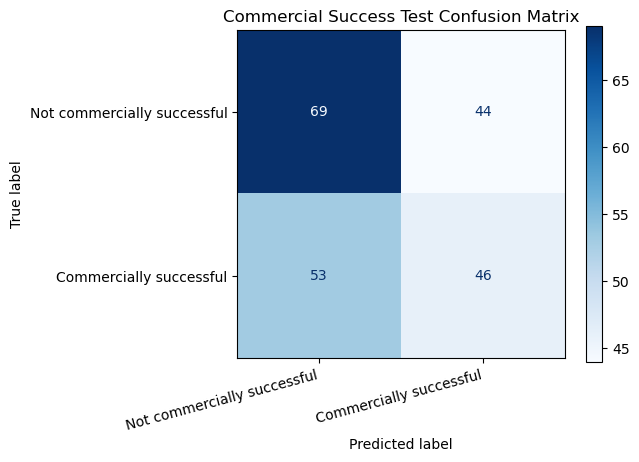

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Evaluate the final trained model on the held-out test set.
model.eval()
all_predictions = []
all_true_labels = []

with torch.no_grad():
    for batch in test_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        budget = batch['budget'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask, budget)
        predictions = outputs.argmax(dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_true_labels.extend(labels.cpu().numpy())

class_names = ['Not commercially successful', 'Commercially successful']
majority_baseline = max(
    sum(label == 0 for label in all_true_labels),
    sum(label == 1 for label in all_true_labels)
) / len(all_true_labels)

print('Final test accuracy:', accuracy_score(all_true_labels, all_predictions))
print('Majority-class baseline:', majority_baseline)
print('\nClassification report:')
print(classification_report(
    all_true_labels,
    all_predictions,
    labels=[0, 1],
    target_names=class_names,
    zero_division=0
))

confusion_matrix_display = ConfusionMatrixDisplay.from_predictions(
    all_true_labels,
    all_predictions,
    labels=[0, 1],
    display_labels=class_names,
    cmap='Blues'
)
confusion_matrix_display.ax_.set_title('Commercial Success Test Confusion Matrix')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()


In [7]:
df_scraped_cleaned = df_scraped_cleaned.copy()

class TextDataset(Dataset):
    def __init__(self, texts, budgets, labels, tokenizer, max_len):
        self.texts = texts.reset_index(drop=True) if hasattr(texts, 'reset_index') else texts
        self.budgets = budgets.reset_index(drop=True) if hasattr(budgets, 'reset_index') else budgets
        self.labels = labels.reset_index(drop=True) if hasattr(labels, 'reset_index') else labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding.input_ids.squeeze(0),
            'attention_mask': encoding.attention_mask.squeeze(0),
            'labels': torch.tensor(int(self.labels[idx]), dtype=torch.long),
            'budget': torch.tensor(float(self.budgets[idx]), dtype=torch.float32)
        }


In [11]:
train_df, test_df = train_test_split(
    df_scraped_cleaned,
    test_size=0.2,
    random_state=42,
    stratify=df_scraped_cleaned['commercial_success']
)
class BertClassifier32(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.drop = nn.Dropout(p=0.3)
        self.budget_encoder = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(),
            nn.LayerNorm(32)
        )
        self.out = nn.Linear(self.bert.config.hidden_size + 32, n_classes)

    def forward(self, input_ids, attention_mask, budget):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = self.drop(outputs.pooler_output)
        budget_output = self.budget_encoder(budget.float().view(-1, 1))
        combined = torch.cat((pooled_output, budget_output), dim=1)
        return self.out(combined)

# Fit StandardScaler on training budgets only to avoid test-set leakage.
budget_scaler = StandardScaler()
train_budgets = budget_scaler.fit_transform(train_df[['Budget']]).flatten()
test_budgets = budget_scaler.transform(test_df[['Budget']]).flatten()

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
train_dataset = TextDataset(
    train_df['Plot'], train_budgets, train_df['commercial_success'], tokenizer, max_len=400
)
test_dataset = TextDataset(
    test_df['Plot'], test_budgets, test_df['commercial_success'], tokenizer, max_len=400
)

train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=16)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_32 = BertClassifier32(n_classes=2).to(device)
optimizer_32 = AdamW(model_32.parameters(), lr=2e-5)
criterion_32 = nn.CrossEntropyLoss()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [15]:
# Train a comparison model with a 32-dimensional budget branch.

num_epochs = 5

for epoch in range(num_epochs):
    model_32.train()
    total_loss = 0.0

    for batch in train_dataloader:
        optimizer_32.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        budget = batch['budget'].to(device)
        labels = batch['labels'].to(device)

        outputs = model_32(input_ids, attention_mask, budget)
        loss = criterion_32(outputs, labels)
        loss.backward()
        optimizer_32.step()
        total_loss += loss.item()

    print(
        f'32-dim model epoch {epoch + 1}/{num_epochs} | '
        f'Loss: {total_loss / len(train_dataloader):.4f}'
    )


32-dim model epoch 1/5 | Loss: 0.6770
32-dim model epoch 2/5 | Loss: 0.6461
32-dim model epoch 3/5 | Loss: 0.5421
32-dim model epoch 4/5 | Loss: 0.3816
32-dim model epoch 5/5 | Loss: 0.1914


32-dimensional model accuracy: 0.5707547169811321
Majority-class baseline: 0.5330188679245284

32-dimensional model classification report:
                             precision    recall  f1-score   support

Not commercially successful       0.56      0.88      0.69       113
    Commercially successful       0.62      0.21      0.32        99

                   accuracy                           0.57       212
                  macro avg       0.59      0.55      0.50       212
               weighted avg       0.59      0.57      0.51       212



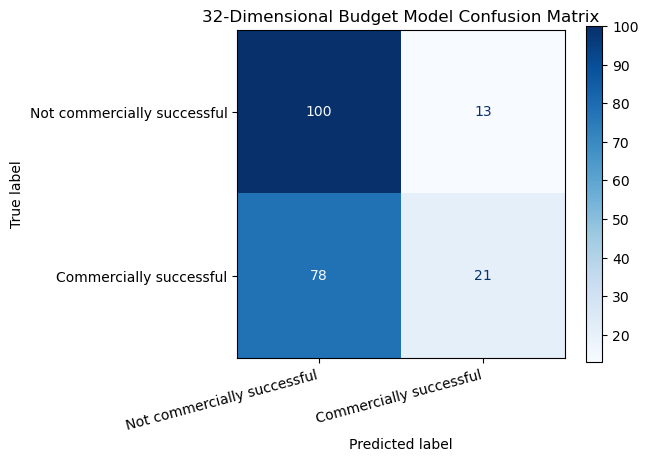

In [17]:


# Evaluate the 32-dimensional budget model on the same held-out test set.
model_32.eval()
all_predictions_32 = []
all_true_labels_32 = []

with torch.no_grad():
    for batch in test_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        budget = batch['budget'].to(device)
        labels = batch['labels'].to(device)

        outputs = model_32(input_ids, attention_mask, budget)
        predictions = outputs.argmax(dim=1)

        all_predictions_32.extend(predictions.cpu().numpy())
        all_true_labels_32.extend(labels.cpu().numpy())

class_names = ['Not commercially successful', 'Commercially successful']
majority_baseline = max(
    sum(label == 0 for label in all_true_labels_32),
    sum(label == 1 for label in all_true_labels_32)
) / len(all_true_labels_32)

print('32-dimensional model accuracy:', accuracy_score(
    all_true_labels_32, all_predictions_32
))
print('Majority-class baseline:', majority_baseline)
print('\n32-dimensional model classification report:')
print(classification_report(
    all_true_labels_32,
    all_predictions_32,
    labels=[0, 1],
    target_names=class_names,
    zero_division=0
))

ConfusionMatrixDisplay.from_predictions(
    all_true_labels_32,
    all_predictions_32,
    labels=[0, 1],
    display_labels=class_names,
    cmap='Blues'
)
plt.title('32-Dimensional Budget Model Confusion Matrix')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()


In [18]:
print(type(model))
print(type(model_32))

<class '__main__.BertClassifier32'>
<class '__main__.BertClassifier32'>


In [ ]:
torch.save({
    "model_state_dict": model.state_dict(),
    "scaler_mean": budget_scaler.mean_,
    "scaler_scale": budget_scaler.scale_
}, "commercial_success_model.pth")

%pip install "numpy<2"